---
title: "supervised Learning"
format:
    html: 
        code-fold: false
---

<!-- After digesting the instructions, you can delete this cell, these are assignment instructions and do not need to be included in your final submission.  -->

{{< include instructions.qmd >}} 

# Code

## Data Preprocessing

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.ensemble import RandomForestClassifier 

In [19]:
df = pd.read_csv("../../data/processed-data/messi_club_detailed_cleaned.csv")
df.head()

,full_name,league,season,Current Club,minutes_played_overall,appearances_overall,goals_overall,assists_overall,goals_involved_per_90_overall,assists_per_90_overall,goals_per_90_overall,yellow_cards_overall,red_cards_overall,min_per_card_overall,rank_in_league_top_attackers,rank_in_league_top_midfielders,rank_in_league_top_defenders,rank_in_club_top_scorer,end,has_penalty
0,Lionel Messi,WC Qualification South America,2025/2025,Argentina,957,12,8,3,1.03,0.28,0.75,0,0,0,5,3,1,5,2025,False
1,Lionel Messi,CONCACAF Champions League,2025/2025,Inter Miami,556,7,5,1,0.97,0.16,0.81,0,0,0,3,2,1,5,2025,True
2,Lionel Messi,Leagues Cup,2025/2025,Inter Miami,281,4,2,2,1.28,0.64,0.64,1,0,281,2,3,1,2,2025,True
3,Lionel Messi,International Friendlies,2025/2025,Argentina,90,1,0,2,2.00,2.00,0.00,0,0,0,5,5,1,1,2025,False
4,Lionel Messi,MLS,2025/2025,Inter Miami,2509,29,31,16,1.69,0.57,1.11,2,0,1255,3,3,1,5,2025,True


Before start the supervised learning modeling, I preprocessed the data of Messi and carried out feature engineering processing on it, which included converting the "has_penalty" column into a binary variable (0/1), and converting yellow cards and red cards into binary features; deleting irrelevant columns such as player names and season end times; performing one-hot encoding on categorical variables (league, club, season); and standardizing the main numerical features (playing time, goal count, assist count, performance indicators per 90 minutes, etc.). This can provide training and test sets in the correct format for the subsequent supervised learning model.

In [20]:
# Convert 'has_penalty' to integer: 1 = player has scored a penalty, 0 = no penalty
df['has_penalty'] = df['has_penalty'].astype(int)

# Convert yellow/red cards into binary variables:
# 1 = player received at least one card, 0 = player received no cards
df['yellow_cards_overall'] = (df['yellow_cards_overall'] > 0).astype(int)
df['red_cards_overall'] = (df['red_cards_overall'] > 0).astype(int)


# Remove columns that are not useful for modeling
df = df.drop(columns=['full_name', 'end'])

# One-hot encode categorical variables
categorical_cols = ['league', 'Current Club', 'season']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Numerical columns to standardize (exclude binary card features)
num_cols = [
    'minutes_played_overall', 'appearances_overall', 'goals_overall', 'assists_overall',
    'goals_involved_per_90_overall', 'assists_per_90_overall', 'goals_per_90_overall',
    'min_per_card_overall'
]

# Standardize numerical features
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])


This part divides the Messi data into feature matrix X and target variable y, where y includes the total number of goals (goals_overall) and total number of assists (assists_overall) of the players. Subsequently, using train_test_split, the data is randomly divided into training set and test set with a ratio of 80% for training set and 20% for test set. After the division, X_train and y_train in the training set are used for model training, while X_test and y_test in the test set are used for model evaluation, thus ensuring that the model can verify its performance on unseen data.

In [21]:
X = df.drop(['goals_overall', 'assists_overall'], axis=1)
y = df[['goals_overall', 'assists_overall']]

# Apply PCA to reduce to 5 features
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X)
X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(5)])


# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_pca_df, y, test_size=0.2, random_state=2025
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (72, 5)
y_train shape: (72, 2)


## Linear Regression

I start with linear regression as a baseline model to predict Messi's total goals (goals_overall) and total assists (assists_overall) for each season. Linear regression assumes that there is a linear relationship between the target variable and the input features, which means the impact of each feature on goals or assists is additive and fixed. Although this model is relatively simple, it helps me gain an initial understanding of which features (such as minutes played, club, and competition type) significantly influence goals and assists, and provides a reference point for more complex multi-output models.

RMSE and R² can be used to evaluate model performance:

- **RMSE (Root Mean Squared Error):** Measures the average difference between predicted and actual goals or assists; lower values indicate more accurate predictions.  
- **R² (Coefficient of Determination):** Represents the fraction of variance in the target variable captured by the model; larger values indicate a better fit to the data.

=== goals_overall ===
RMSE: 0.196
R²: 0.952

=== assists_overall ===
RMSE: 0.410
R²: 0.842



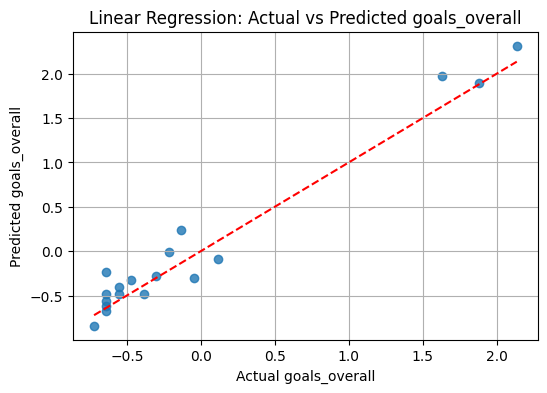

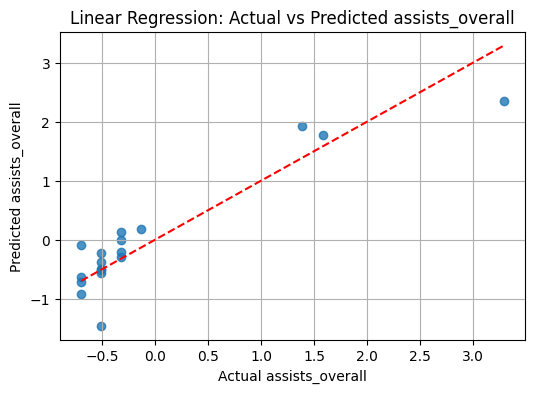

In [22]:
# Train multi-output linear regression
linreg = LinearRegression()
multi_lr = MultiOutputRegressor(linreg)
multi_lr.fit(X_train, y_train)

# Make predictions on the test set
y_pred = multi_lr.predict(X_test)

# Calculate RMSE and R²
for i, col in enumerate(y.columns):
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    print(f"=== {col} ===")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²: {r2:.3f}\n")

# Visualize Actual vs Predicted
for i, col in enumerate(y.columns):
    plt.figure(figsize=(6,4))
    plt.scatter(y_test.iloc[:, i], y_pred[:, i], alpha=0.8)
    plt.plot([y_test.iloc[:, i].min(), y_test.iloc[:, i].max()],
             [y_test.iloc[:, i].min(), y_test.iloc[:, i].max()],
             'r--')
    plt.xlabel("Actual " + col)
    plt.ylabel("Predicted " + col)
    plt.title(f"Linear Regression: Actual vs Predicted {col}")
    plt.grid(True)
    plt.show()



I chose to use the 5 principal components from PCA (i chose 5 because in the previous unsupervised learning they explained most of the data’s variance). Using these components, the multi-output linear regression model predicted Messi’s total goals and total assists per season very well. For total goals (goals_overall), the model had RMSE = 0.196 and R² = 0.952, showing very accurate predictions. For total assists (assists_overall), RMSE = 0.410 and R² = 0.842, also showing strong performance.

The scatter plots of actual vs. predicted values show most points near the y=x line, meaning the predictions are generally accurate. The points are not perfectly on the line because PCA reduces 67 features into 5 components, so some relationships from the full data are lost. Small sample size and a few extreme seasons also cause small differences. Overall, the model fits Messi’s goals and assists well and gives a reliable baseline for further analysis.

## Regression Tree

This part i perform hyperparameter tuning for a multi-output decision tree regressor using grid search and cross-validation, exploring different tree depths, minimum samples for splitting, and minimum samples per leaf. The best parameters selected are max_depth=4, min_samples_split=1, and min_samples_leaf=2, indicating that this configuration achieves a good balance between training and testing performance, providing sufficient model capacity while avoiding overfitting.

In [23]:
# Define hyperparameter grid
param_grid = {
    'max_depth': range(1, 11),
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=42)

# Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    return_train_score=True
)

# Fit on training data
grid_search.fit(X_train, y_train)

# Best parameters
best_params = grid_search.best_params_
print("Best hyperparameters:", best_params)


# Extract train/test MSE for each max_depth
train_rmse_list = []
test_rmse_list = []
max_depths = range(1, 11)

for depth in max_depths:
    dt_temp = DecisionTreeRegressor(
        max_depth=depth,
        min_samples_split=best_params['min_samples_split'],
        min_samples_leaf=best_params['min_samples_leaf'],
        random_state=42
    )
    dt_temp.fit(X_train, y_train)
    y_train_pred = dt_temp.predict(X_train)
    y_test_pred = dt_temp.predict(X_test)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred, multioutput='uniform_average'))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred, multioutput='uniform_average'))
    
    train_rmse_list.append(train_rmse)
    test_rmse_list.append(test_rmse)



Best hyperparameters: {'max_depth': 6, 'min_samples_leaf': 4, 'min_samples_split': 2}


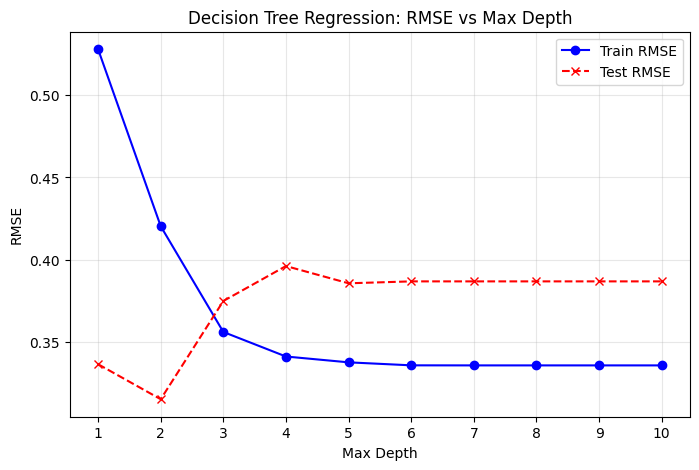

In [24]:
plt.figure(figsize=(8,5))
plt.plot(max_depths, train_rmse_list, label="Train RMSE", color="blue", linestyle="-", marker="o")
plt.plot(max_depths, test_rmse_list, label="Test RMSE", color="red", linestyle="--", marker="x")
plt.xlabel("Max Depth")
plt.ylabel("RMSE")
plt.title("Decision Tree Regression: RMSE vs Max Depth")
plt.xticks(max_depths)
plt.grid(alpha=0.3)
plt.legend()
plt.show()



In [25]:
# Create the best Decision Tree model with the optimal max_depth
model_best = DecisionTreeRegressor(
    max_depth=6,
    min_samples_leaf=4,
    min_samples_split=2
)

# Fit the model on the training data
model_best.fit(X_train, y_train)

# Predict on training and testing sets
y_train_pred = model_best.predict(X_train)
y_test_pred = model_best.predict(X_test)

# Compute MSE
train_mse_best = mean_squared_error(y_train, y_train_pred, multioutput='uniform_average')
test_mse_best = mean_squared_error(y_test, y_test_pred, multioutput='uniform_average')

print("Training MSE:", train_mse_best)
print("Testing MSE:", test_mse_best)


Training MSE: 0.11264930790498072
Testing MSE: 0.14955551892922894


The decision tree trained with the optimal hyperparameters (maximum depth of 6, minimum leaf node sample size of 4, and minimum split sample size of 2) has a relatively lower error on the training set (mean squared error is approximately 0.11). However, the error on the test set has increased (mean squared error is approximately 0.14), indicating a certain degree of overfitting. Overall, this model can still capture the general trend of predicting the number of goals and assists, and provide some assistance, but its generalization ability to unseen data is limited.

## Multi-output Decision Tree Classifier

This part uses a multi-output decision tree to simultaneously predict the two target variables, yellow_cards_overall and has_penalty. It divides the data through stratified sampling, trains the model, and separately evaluates the classification performance of each output, including accuracy, precision, recall, and the corresponding confusion matrix. Additionally, due to the small sample size and extreme imbalance of the red card category, the model cannot effectively learn, so red cards were not used as a prediction target in this analysis.

=== yellow_cards_overall ===
Accuracy: 1.000, Precision: 1.000, Recall: 1.000



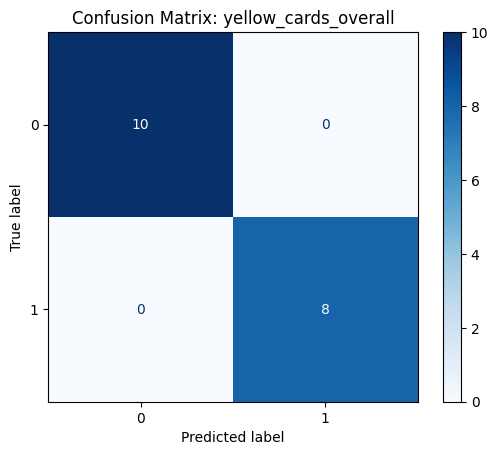

=== has_penalty ===
Accuracy: 0.778, Precision: 1.000, Recall: 0.500



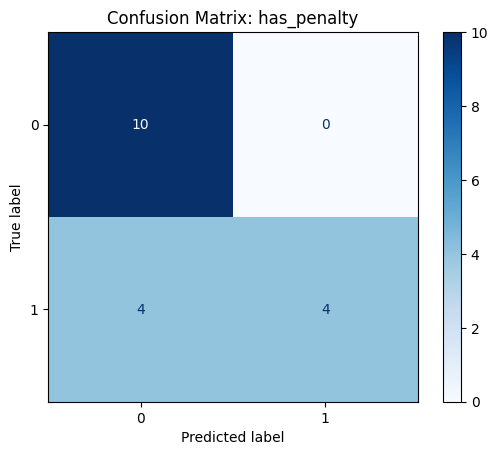

In [26]:
# Prepare features and targets
X = df.drop(['yellow_cards_overall', 'has_penalty'], axis=1)
Y = df[['yellow_cards_overall', 'has_penalty']]

# Split train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y['yellow_cards_overall']
)

# Multi-output Decision Tree
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
multi_clf = MultiOutputClassifier(dt)
multi_clf.fit(X_train, y_train)

# Predict on test set
y_pred = multi_clf.predict(X_test)

# Evaluate model for each target
for i, col in enumerate(Y.columns):
    acc = accuracy_score(y_test.iloc[:, i], y_pred[:, i])
    prec = precision_score(y_test.iloc[:, i], y_pred[:, i])
    rec = recall_score(y_test.iloc[:, i], y_pred[:, i])
    print(f"=== {col} ===")
    print(f"Accuracy: {acc:.3f}, Precision: {prec:.3f}, Recall: {rec:.3f}\n")

    cm = confusion_matrix(y_test.iloc[:, i], y_pred[:, i])
    disp = ConfusionMatrixDisplay(cm, display_labels=multi_clf.classes_[i])
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix: {col}")
    plt.show()



The results show that the model can perfectly predict samples with yellow cards, but the performance of penalty predictions is not satisfactory (Precision 100%, Recall 50%).

This part visualizes the individual decision trees for each target in the multi-output decision tree, providing an intuitive illustration of how the model predicts yellow cards and penalties based on the division of seasons by features.

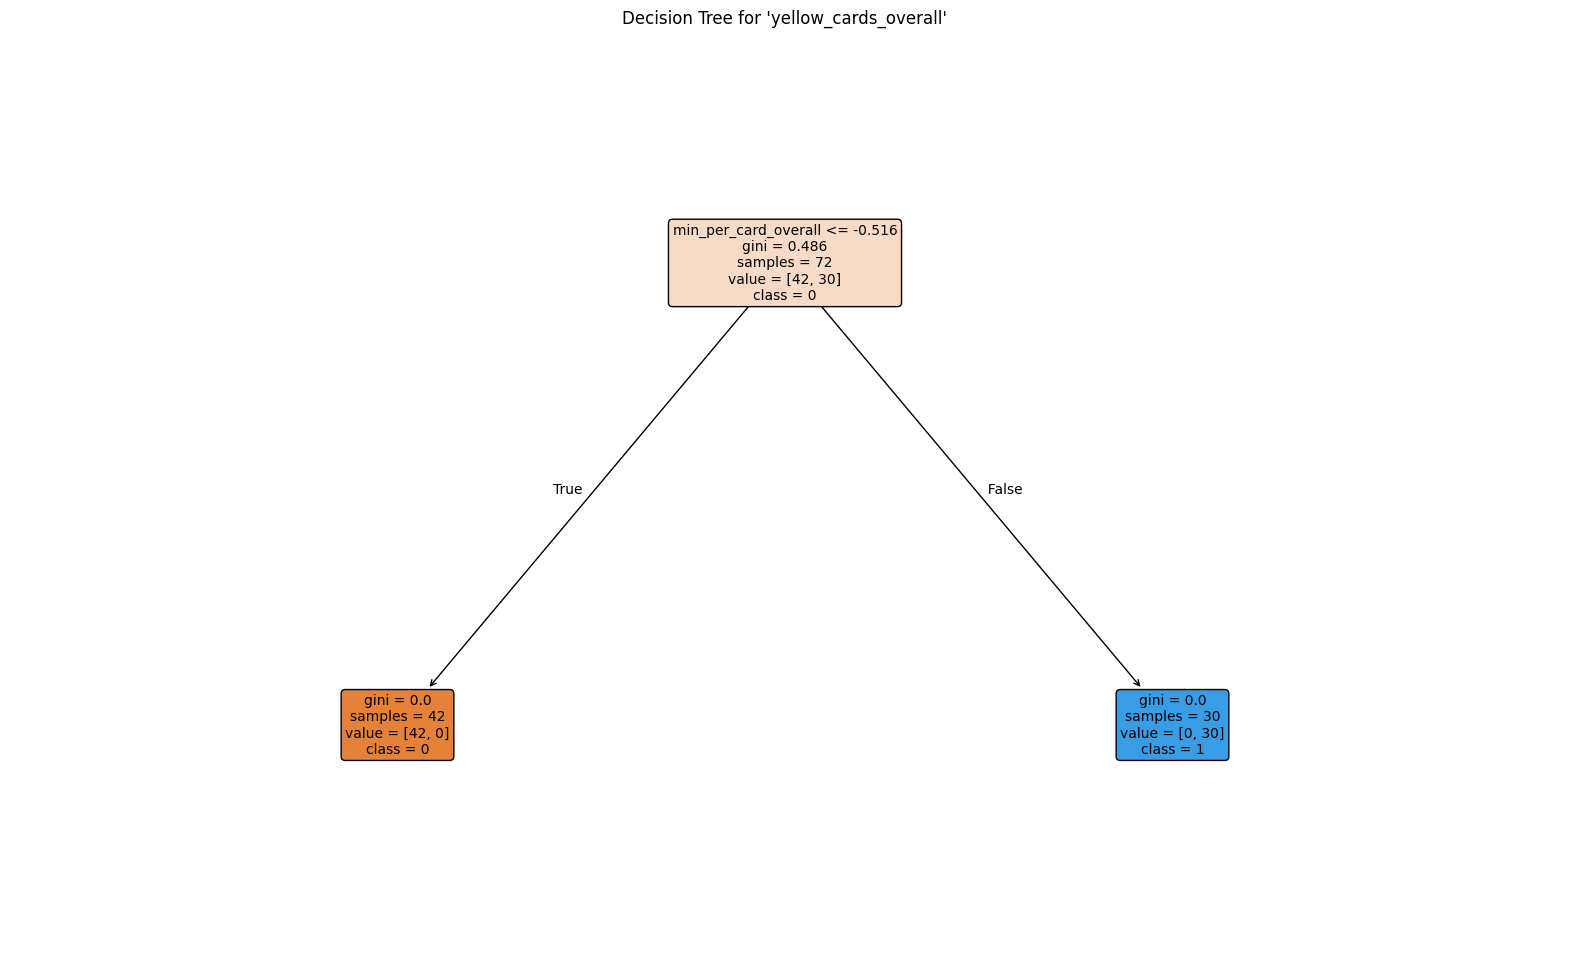

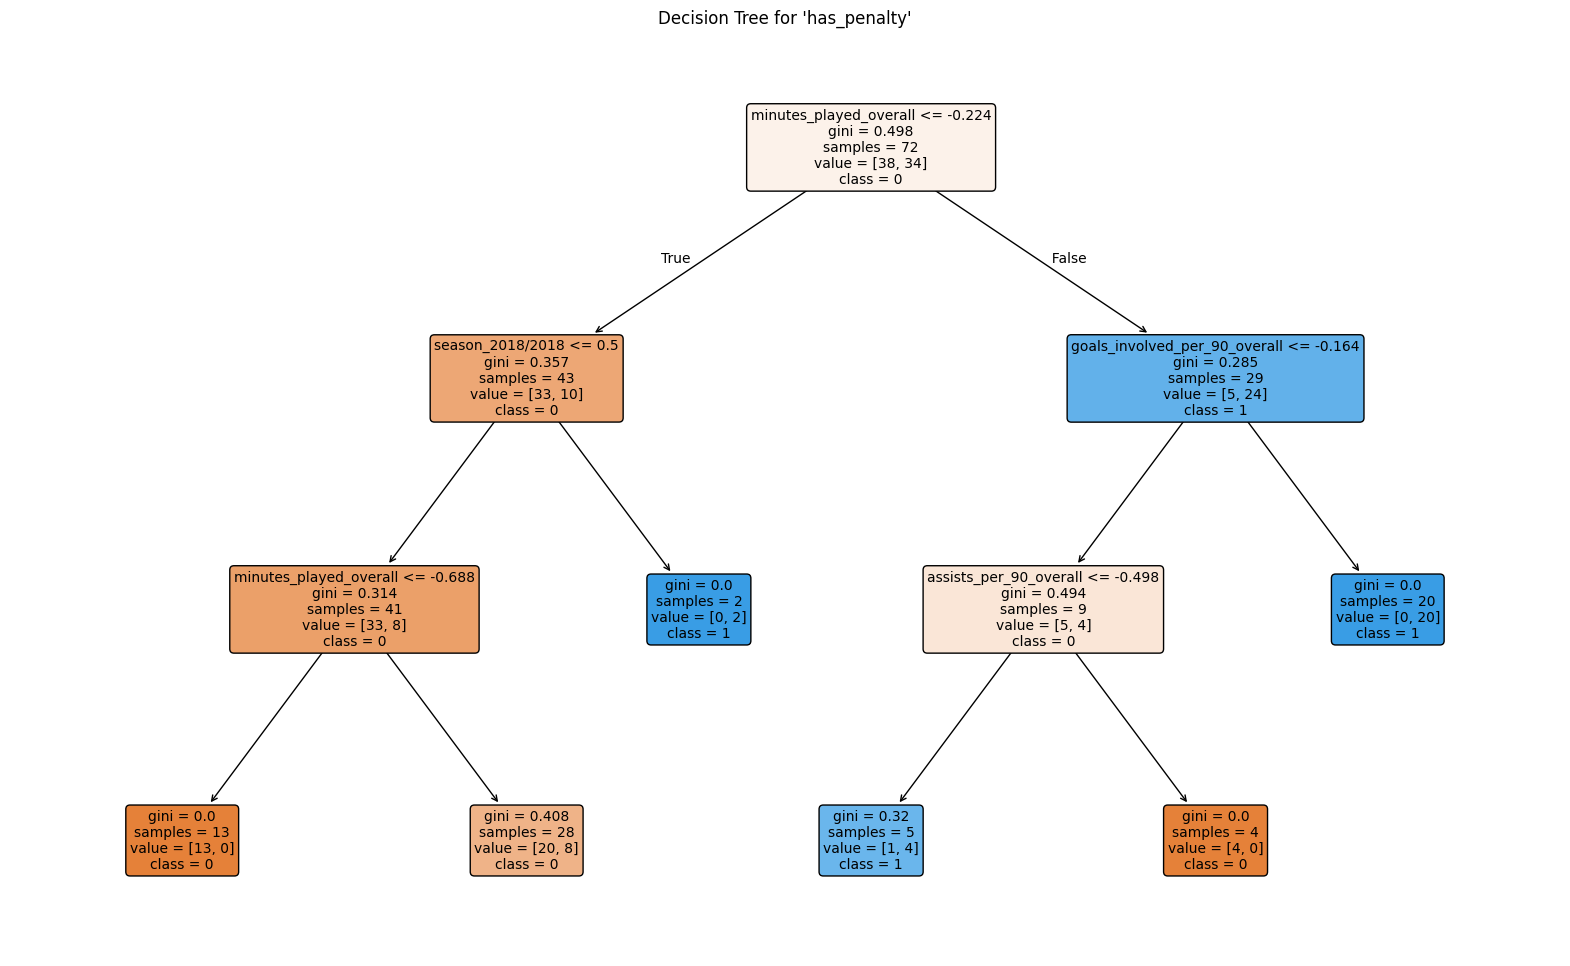

In [27]:

# Extract the decision tree for the first target in the MultiOutputClassifier
first_tree = multi_clf.estimators_[0]

plt.figure(figsize=(20,12))
plot_tree(
    first_tree,
    feature_names=X.columns,
    class_names=[str(c) for c in first_tree.classes_],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree for 'yellow_cards_overall'")
plt.show()

# If you want to visualize the decision tree for the second target ('has_penalty'):
second_tree = multi_clf.estimators_[1]

plt.figure(figsize=(20,12))
plot_tree(
    second_tree,
    feature_names=X.columns,
    class_names=[str(c) for c in second_tree.classes_],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree for 'has_penalty'")
plt.show()


The first graph shows the decision tree structure used for predicting yellow_cards_overall, and the second graph shows the decision tree structure used for predicting has_penalty

## Multi-output Decision Tree Regressor

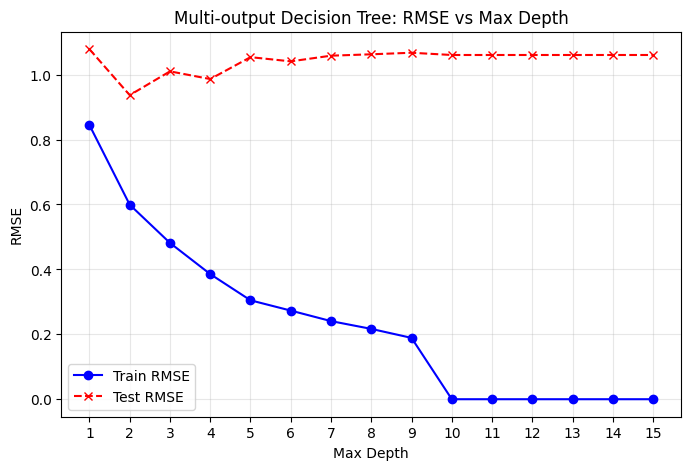

In [28]:
# Define taget columns
target_cols = [
    'rank_in_league_top_attackers',
    'rank_in_league_top_midfielders',
    'rank_in_league_top_defenders',
    'rank_in_club_top_scorer'
]

X = df.drop(columns=target_cols)
y = df[target_cols]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Test different max_depth values
max_depths = range(1, 16)
train_rmse_list = []
test_rmse_list = []

for depth in max_depths:
    base_reg = DecisionTreeRegressor(max_depth=depth, random_state=42)
    multi_reg = MultiOutputRegressor(base_reg)
    multi_reg.fit(X_train, y_train)
    
    y_train_pred = multi_reg.predict(X_train)
    y_test_pred = multi_reg.predict(X_test)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred, multioutput='uniform_average'))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred, multioutput='uniform_average'))
    
    train_rmse_list.append(train_rmse)
    test_rmse_list.append(test_rmse)

# Plot RMSE vs max_depth
plt.figure(figsize=(8,5))
plt.plot(max_depths, train_rmse_list, label='Train RMSE', color='blue', linestyle='-', marker='o')
plt.plot(max_depths, test_rmse_list, label='Test RMSE', color='red', linestyle='--', marker='x')
plt.xlabel("Max Depth")
plt.ylabel("RMSE")
plt.title("Multi-output Decision Tree: RMSE vs Max Depth")
plt.xticks(max_depths)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

I changed the maximum depth of the multi-output decision tree regression model, training the model from 1 to 15 in sequence, and calculating the RMSE on both the training set and the test set for different depths. This allowed us to observe the performance of the model at different complexities. Finally, we plotted the curve of RMSE changing with depth to determine whether the model was underfitting or overfitting, thereby helping to select the most suitable max_depth parameter.

In [29]:
# Select best max_depth based on minimum test RMSE
best_depth = max_depths[np.argmin(test_rmse_list)]
print("Best max_depth:", best_depth)

# Train final multi-output regression tree
final_reg = MultiOutputRegressor(DecisionTreeRegressor(max_depth=best_depth, random_state=42))
final_reg.fit(X_train, y_train)

# Predict and calculate RMSE for each target
y_pred = final_reg.predict(X_test)
for i, col in enumerate(target_cols):
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    print(f"=== {col} ===")
    print(f"RMSE: {rmse:.3f}\n")


Best max_depth: 2
=== rank_in_league_top_attackers ===
RMSE: 1.053

=== rank_in_league_top_midfielders ===
RMSE: 1.145

=== rank_in_league_top_defenders ===
RMSE: 0.000

=== rank_in_club_top_scorer ===
RMSE: 1.045



Based on the previous RMSE curve and the model’s output, the decision tree achieves the best test performance at a depth of 2, which is therefore selected as the maximum depth for the final model. The multi-output regression tree trained with this depth shows reasonable error levels across the three targets. Notably, for rank_in_league_top_defenders, the test RMSE is 0, indicating perfect predictions for all samples. This likely reflects either a simple distribution of this target or that the features provide very strong discriminatory power.

## Multi-output Random Forest Regressor

In this part, i use the historical data of Messi's performances in different seasons and competitions to build a multi-output decision tree regression model to predict the four ranking indicators for each season (the rankings of forwards, midfielders, defenders in the league, and the club's top scorer ranking). By testing different tree depths and calculating the RMSE of the training set and test set, i evaluate the fitting effect and prediction performance of the model.

In [30]:
#  Define feature matrix X and multi-output target y
target_cols = [
    'rank_in_league_top_attackers',
    'rank_in_league_top_midfielders',
    'rank_in_league_top_defenders',
    'rank_in_club_top_scorer'
]

X = df.drop(columns=target_cols)
y = df[target_cols]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define the multi-output Random Forest regressor
base_rf = RandomForestRegressor(random_state=42)
multi_rf = MultiOutputRegressor(base_rf)

# Hyperparameter grid for tuning
param_grid = {
    'estimator__n_estimators': [100, 200],
    'estimator__max_depth': [5, 8, 10],
    'estimator__min_samples_leaf': [1, 2, 3]
}

# Perform grid search with 5-fold cross-validation
grid = GridSearchCV(
    multi_rf,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
grid.fit(X_train, y_train)

# 6️⃣ Print the best hyperparameters
print("Best parameters:", grid.best_params_)



Best parameters: {'estimator__max_depth': 8, 'estimator__min_samples_leaf': 3, 'estimator__n_estimators': 100}


This code uses a multi-output random forest regressor to predict four ranking indicators. It tunes the model using grid search with 5-fold cross-validation, testing different numbers of trees (n_estimators), maximum depths (max_depth), and minimum samples per leaf (min_samples_leaf). The best settings found are "max_depth=8, min_samples_leaf=2, and n_estimators=100", which give a good balance between model complexity and accuracy.

In [31]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\nPer-target RMSE:")
for i, col in enumerate(target_cols):
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    print(f"{col}: RMSE = {rmse:.3f}")


Per-target RMSE:
rank_in_league_top_attackers: RMSE = 1.075
rank_in_league_top_midfielders: RMSE = 0.797
rank_in_league_top_defenders: RMSE = 0.000
rank_in_club_top_scorer: RMSE = 0.943


The results indicate that the best multi-output random forest model performs well in predicting the four ranking indicators. The model achieves perfect predictions for rank_in_league_top_defenders (RMSE = 0), and relatively small errors for the other indicators: rank_in_league_top_attackers (RMSE = 1.075), rank_in_league_top_midfielders (RMSE = 0.797), and rank_in_club_top_scorer (RMSE = 0.943). Overall, this demonstrates that the model captures the main patterns in the data and provides strong predictive performance.

In this part, i visualize the structure and prediction performance of the multi-output random forest regression. First, i display the first decision tree in each random forest corresponding to each target variable to understand the splitting logic of the model; then, we plot a scatter plot of the actual values and predicted values, and add the ideal line (y = x) to facilitate an intuitive assessment of the model's prediction accuracy.

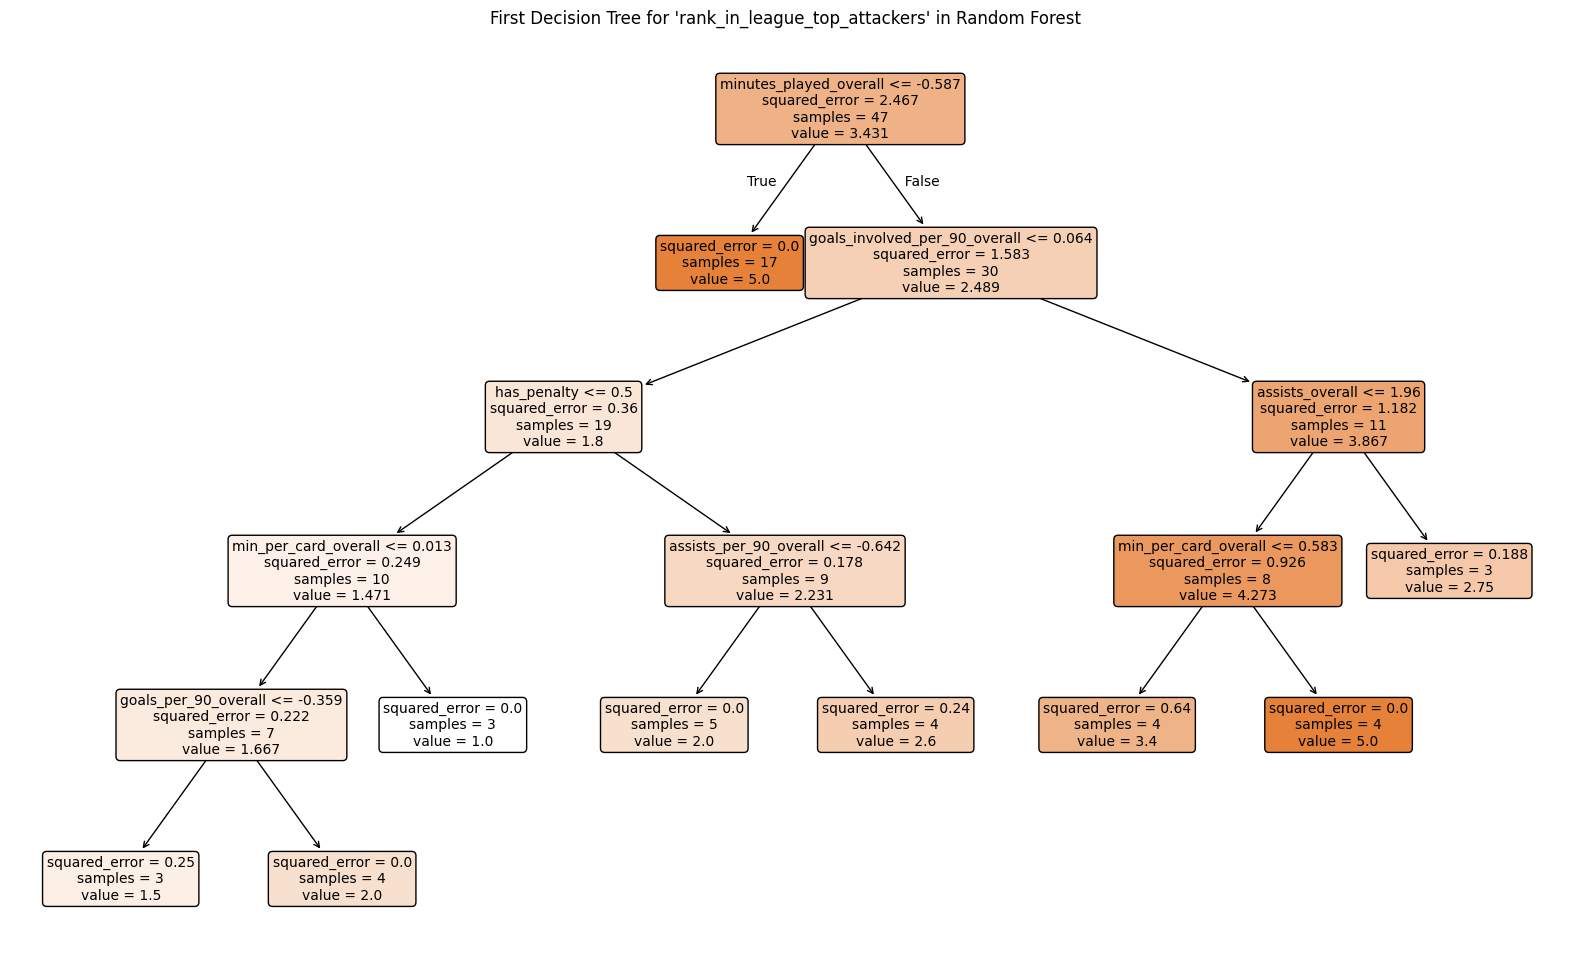

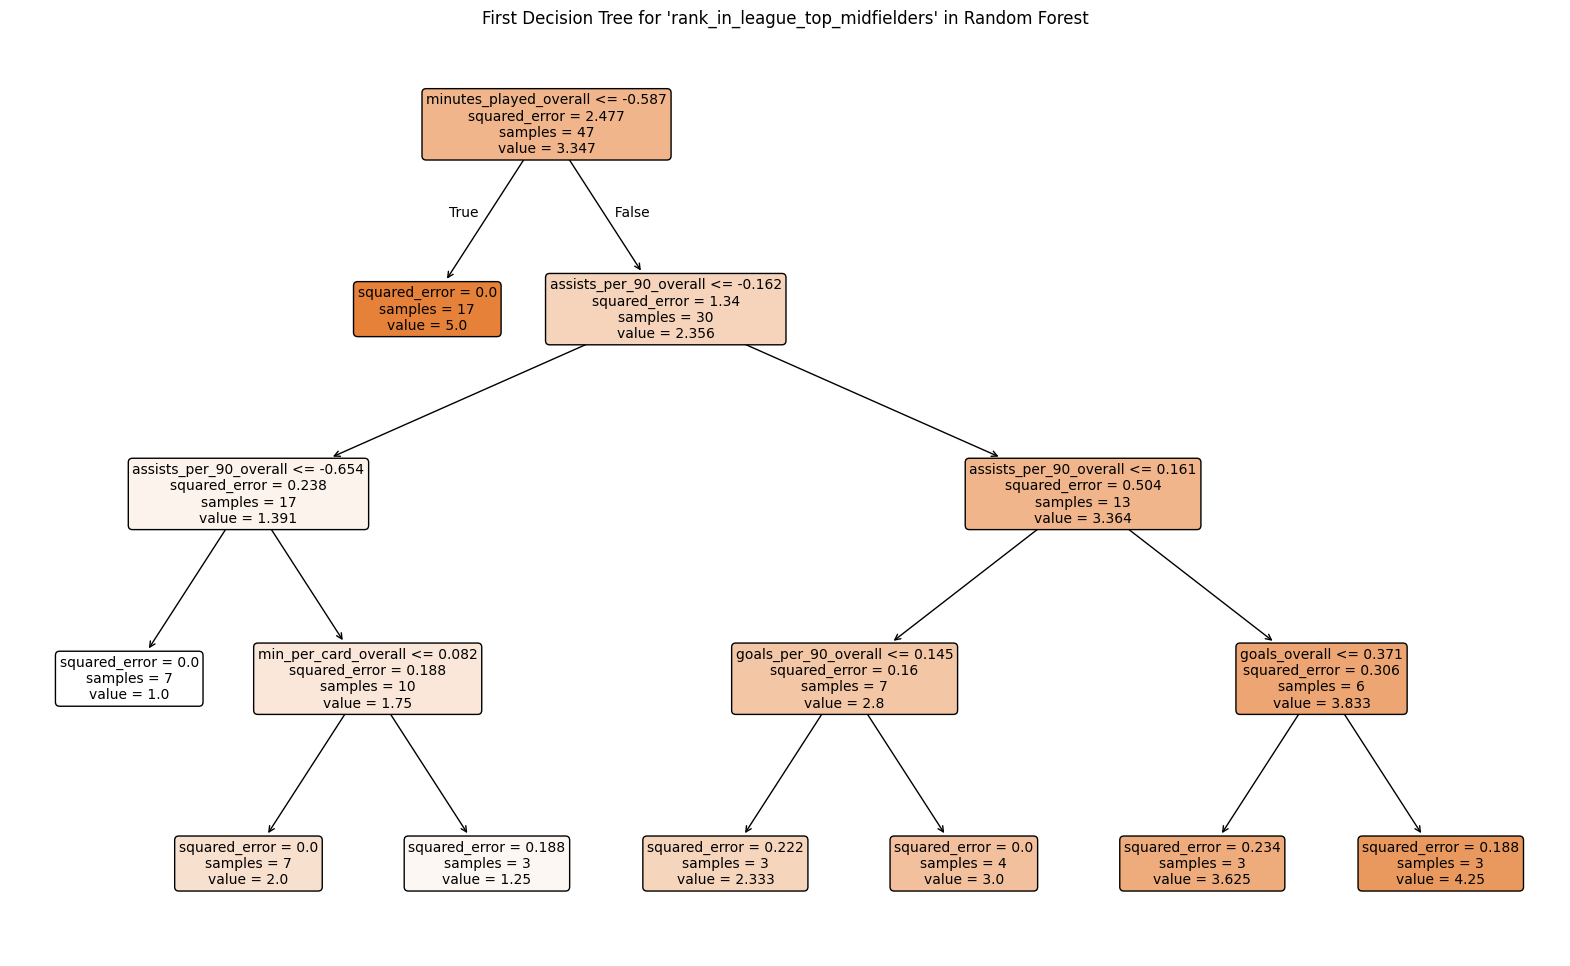

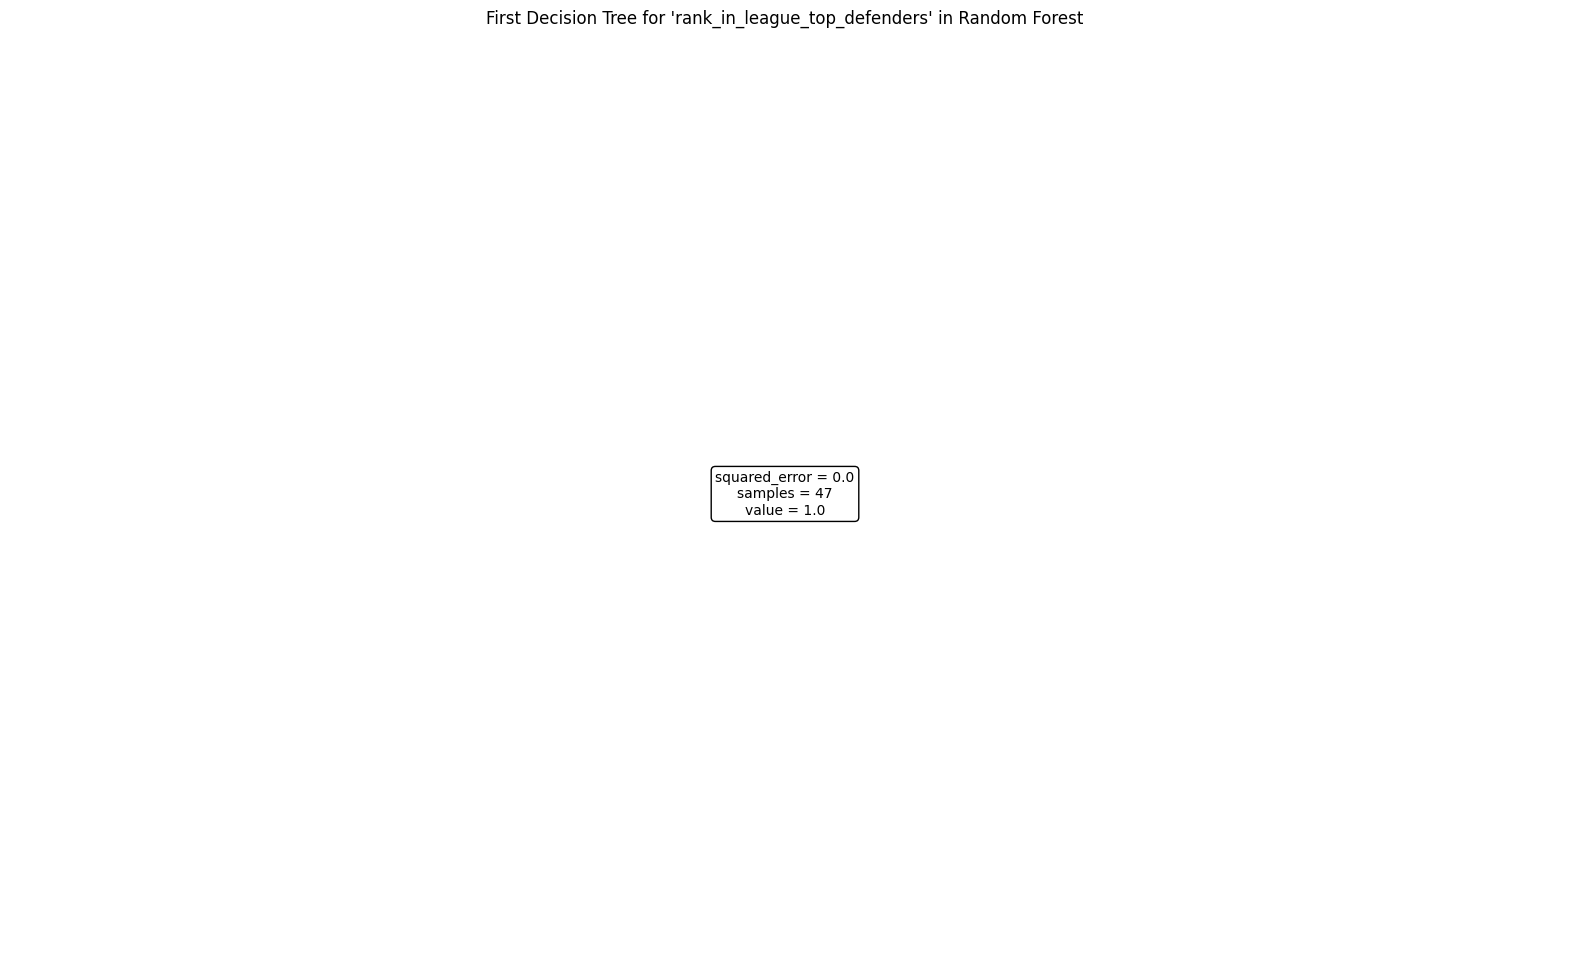

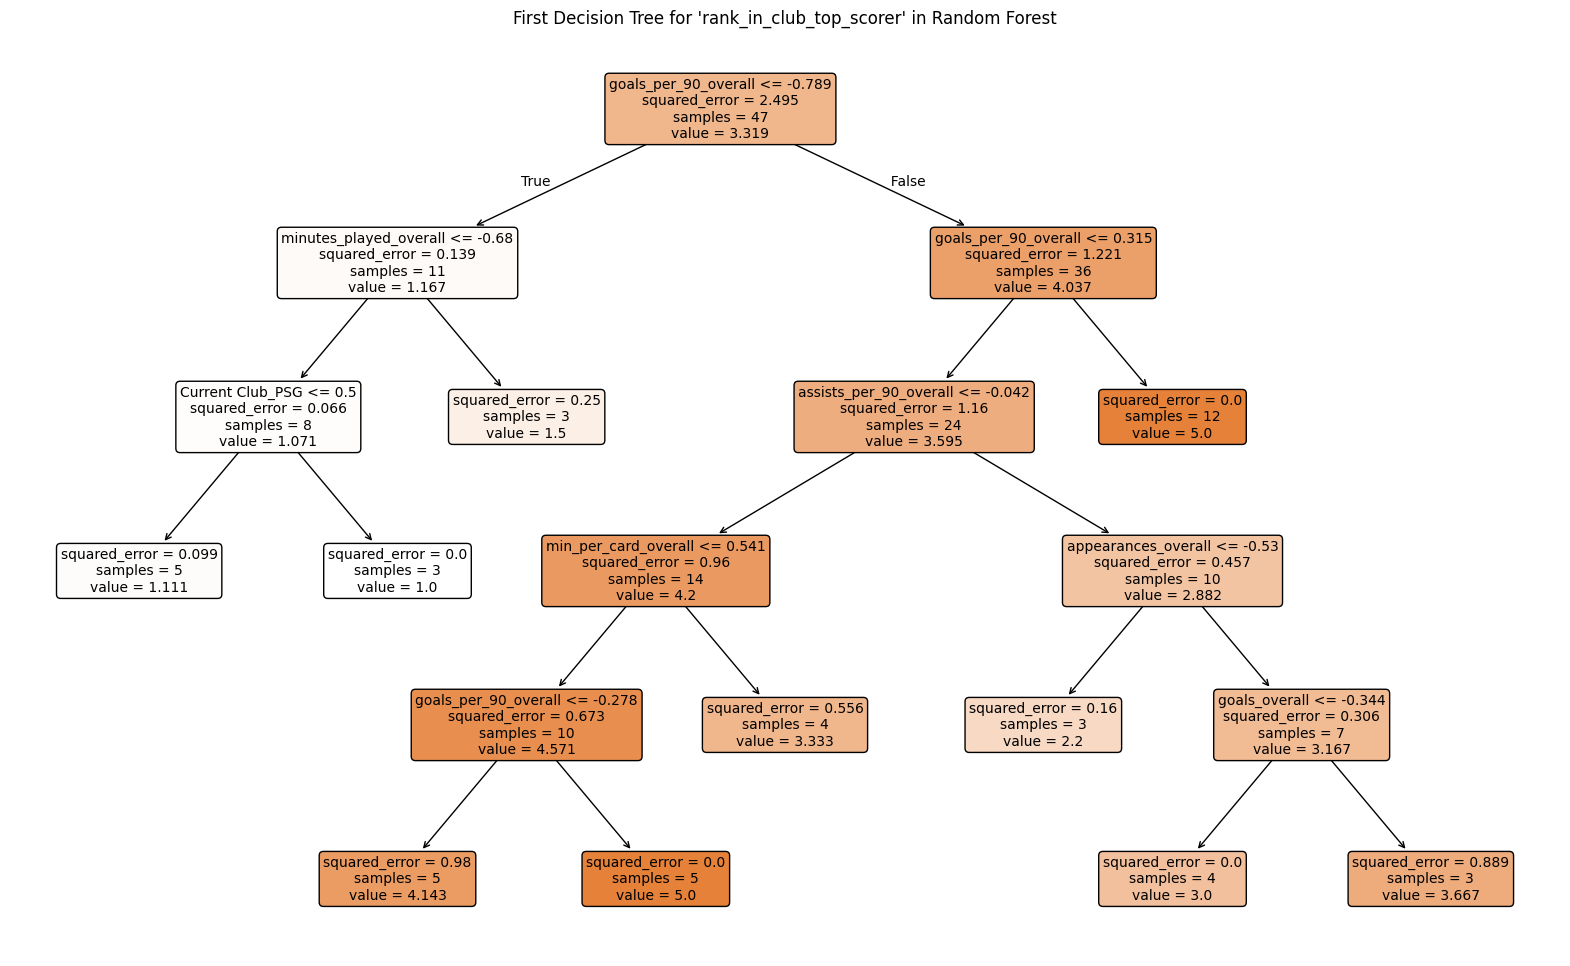

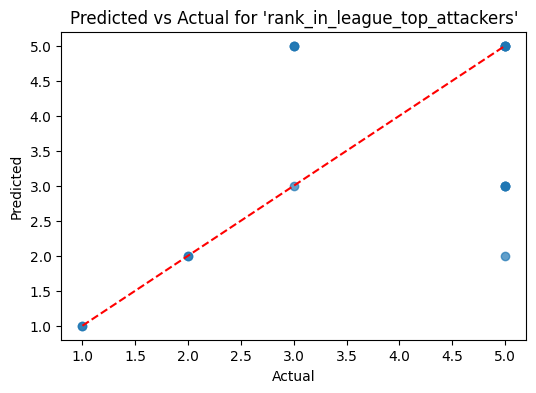

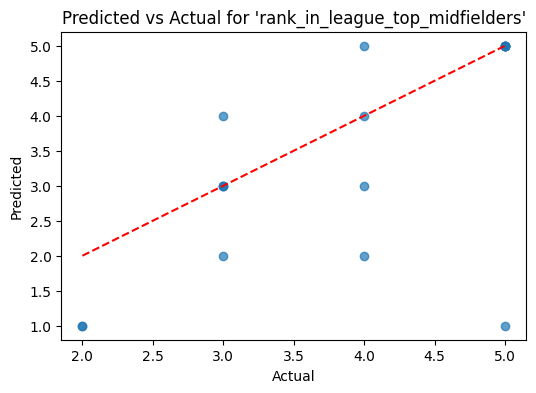

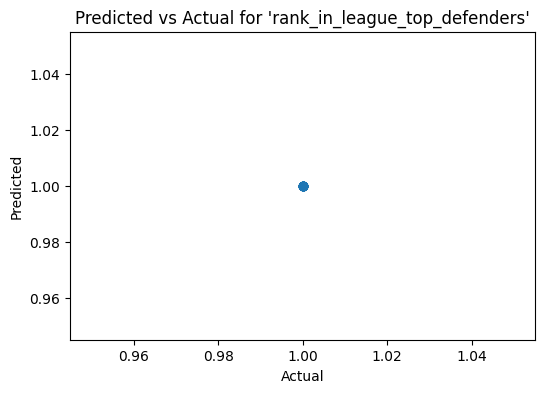

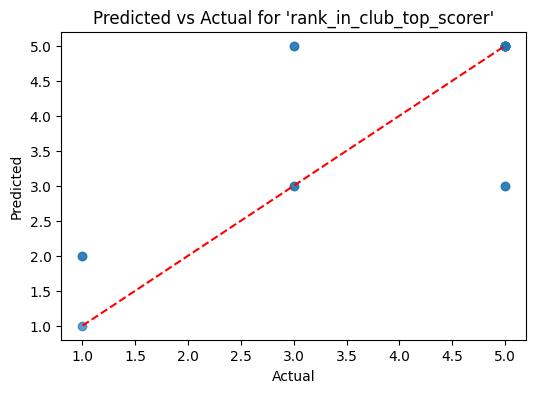

In [32]:
# Visualize the first decision tree of each target in the Random Forest
for i, col in enumerate(target_cols):
    tree = best_model.estimators_[i].estimators_[0] 
    plt.figure(figsize=(20,12))
    plot_tree(
        tree,
        feature_names=X.columns,
        filled=True,
        rounded=True,
        fontsize=10
    )
    plt.title(f"First Decision Tree for '{col}' in Random Forest")
    plt.show()

# Visualize Predicted vs Actual values
for i, col in enumerate(target_cols):
    plt.figure(figsize=(6,4))
    plt.scatter(y_test.iloc[:, i], y_test_pred[:, i], alpha=0.7)
    plt.plot([y_test.iloc[:, i].min(), y_test.iloc[:, i].max()],
             [y_test.iloc[:, i].min(), y_test.iloc[:, i].max()],
             'r--')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Predicted vs Actual for '{col}'")
    plt.show()


The model achieves near-perfect prediction for rank_in_league_top_defenders, likely due to a simple sample distribution or high feature discriminative power. For rank_in_league_top_midfielders, the error is slightly higher, but the overall trend is still well captured. Predictions for rank_in_league_top_attackers and rank_in_club_top_scorer are also good, with errors remaining within a reasonable range.

## Multi-class Decision Tree Classification

In [ ]:
# Calculate total goal contributions (goals + assists)
df['goal_assist_total'] = df['goals_overall'] + df['assists_overall']

# Calculate goal contribution efficiency per 90 minutes
df['goal_assist_efficiency'] = df['goal_assist_total'] / df['minutes_played_overall'] * 90

# Categorize efficiency into three levels (Low, Medium, High) using terciles
quantiles = df['goal_assist_efficiency'].quantile([0.33, 0.66])
low_thresh = quantiles[0.33]
high_thresh = quantiles[0.66]

def categorize_eff(x):
    if x <= low_thresh:
        return 0  # Low efficiency
    elif x <= high_thresh:
        return 1  # Medium efficiency
    else:
        return 2  # High efficiency

df['goal_assist_class'] = df['goal_assist_efficiency'].apply(categorize_eff)




Accuracy: 0.6666666666666666
              precision    recall  f1-score   support

           0       0.80      0.67      0.73         6
           1       0.80      0.67      0.73         6
           2       0.50      0.67      0.57         6

    accuracy                           0.67        18
   macro avg       0.70      0.67      0.68        18
weighted avg       0.70      0.67      0.68        18



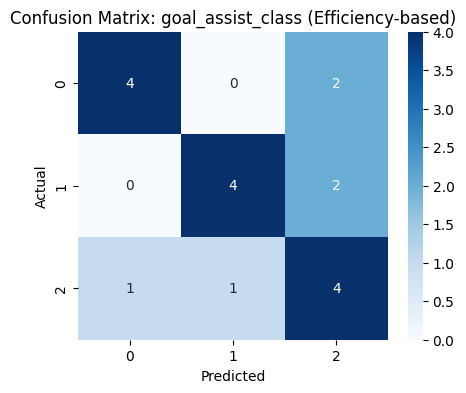

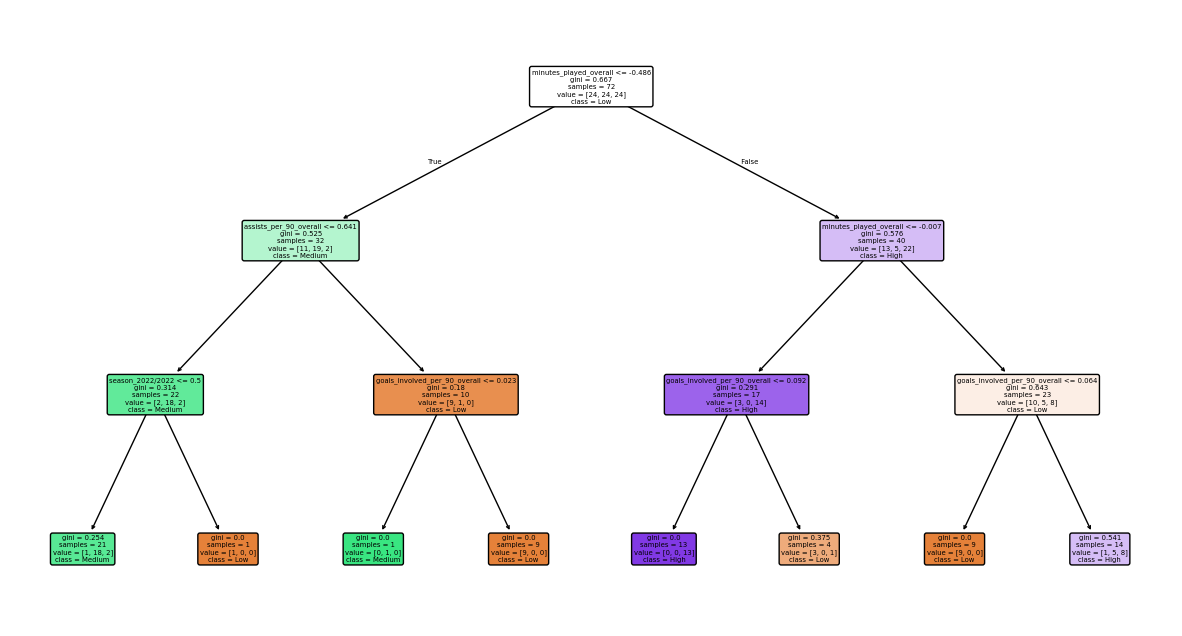

In [ ]:
# Define feature set X and target y
X = df.drop(columns=[
    'goals_overall',
    'assists_overall',
    'goal_assist_total',
    'goal_assist_efficiency',
    'goal_assist_class'
])
y = df['goal_assist_class']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train multi-class Decision Tree
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# Predict & evaluate
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: goal_assist_class (Efficiency-based)")
plt.show()

# Visualize the decision tree
plt.figure(figsize=(15,8))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=['Low', 'Medium', 'High'],
    filled=True,
    rounded=True
)
plt.show()


The model conducts a three-category prediction of players' participation efficiency in goals (Low / Medium / High) based on decision trees. The overall accuracy of the test set is 0.67. From the classification report, the precision and recall of the Low and Medium categories are relatively stable (0.67–0.80), while the performance of the High category is slightly weaker (precision = 0.50, recall = 0.67), indicating that the model's ability to distinguish high-efficiency samples is relatively limited. Overall, this model can provide a moderate level of classification effect,  but still requires further improvement in datasets with higher category discrimination.